In [48]:
import pickle
import numpy as np

from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

# 1. Завантаження даних

In [49]:
!wget -O mod_05_topic_10_various_data.pkl \
https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl

--2026-07-23 11:17:31--  https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18343147 (17M) [application/octet-stream]
Saving to: ‘mod_05_topic_10_various_data.pkl’

mod_05_topic_10_var 100%[===================>]  17.49M  --.-KB/s    in 0.06s   

2026-07-23 11:17:31 (271 MB/s) - ‘mod_05_topic_10_various_data.pkl’ saved [18343147/18343147]



In [50]:
with open("mod_05_topic_10_various_data.pkl", "rb") as fl:
    datasets = pickle.load(fl)

In [51]:
data = datasets['concrete']
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cement               427 non-null    float64
 1   BlastFurnaceSlag     427 non-null    float64
 2   FlyAsh               427 non-null    float64
 3   Water                427 non-null    float64
 4   Superplasticizer     427 non-null    float64
 5   CoarseAggregate      427 non-null    float64
 6   FineAggregate        427 non-null    float64
 7   CompressiveStrength  427 non-null    float64
dtypes: float64(8)
memory usage: 26.8 KB


In [52]:
data.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31


In [53]:
data.duplicated().sum()

np.int64(0)

# 2. Створення ознаки Components

In [54]:
components = ['Cement',
              'BlastFurnaceSlag',
              'FlyAsh',
              'Water',
              'Superplasticizer',
              'CoarseAggregate',
              'FineAggregate']

data['Components'] = data[components].gt(0).sum(axis=1)

data[components + ['Components']].head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,5
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,5
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,5
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,5
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,7


# 3. Нормалізуємо набір даних

In [55]:
scaler = StandardScaler().set_output(transform='pandas')

# CompressiveStrength цільова змінна, тому її виключаємо з ознак. Кластеризація виконана лише за складом бетонної суміші.

X = scaler.fit_transform(data.drop(columns=["CompressiveStrength"]))

# 4. Визначаємо оптимальну кількість кластерів

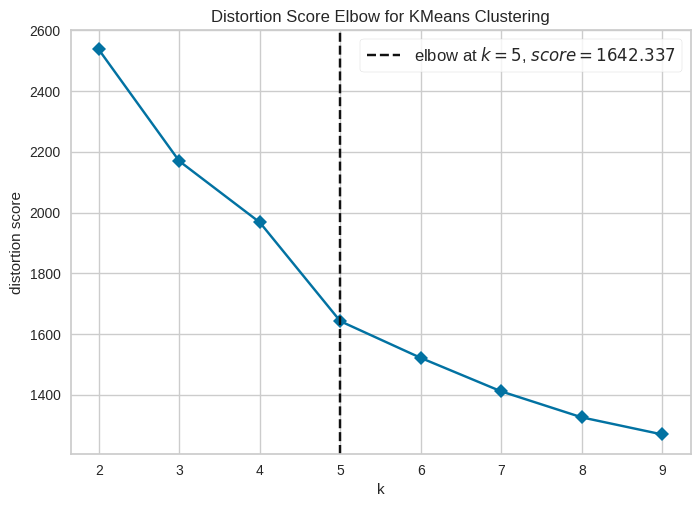

In [56]:
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2, 10), timings=False)

visualizer.fit(X)

visualizer.show()

k_value = visualizer.elbow_value_

# 5. Кластеризація методом k-середніх

In [57]:
model_kmn = KMeans(random_state=42, n_clusters=k_value).fit(X)

data['Cluster'] = model_kmn.labels_

# 6. Розрахунок описової статистики

In [58]:
data['Count'] = data.groupby('Cluster')['Cluster'].transform('count')
report = data.groupby('Cluster').median()
report

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components,Count
Cluster,,,,,,,,,,
0,212.3,0.00,125.2,169.95,9.9,1002.0,795.55,39.880,6.0,84.0
1,186.2,183.40,0.0,190.00,0.0,977.0,734.30,37.430,5.0,85.0
2,193.0,119.25,116.0,193.55,8.5,879.6,744.10,33.175,7.0,118.0
3,356.0,121.00,0.0,162.00,10.0,914.3,803.70,59.000,6.0,53.0
4,342.0,0.00,0.0,186.00,0.0,1040.0,774.00,36.940,4.0,87.0


# 7. Аналіз звіту

У результаті кластеризації було виділено п'ять груп бетонних сумішей, які відрізняються складом компонентів і рівнем міцності.

**Кластер 0** (84 рецептури) об'єднує суміші із золою-винесенням (FlyAsh) та суперпластифікатором (Superplasticizer), але без доменного шлаку (BlastFurnaceSlag). При помірному вмісті цементу (Cement) ці рецептури забезпечують достатньо високу медіанну міцність — 39,88 МПа.

**Кластер 1** (85 рецептур) характеризується використанням доменного шлаку без золи-винесення та суперпластифікатора. Незважаючи на найменшу кількість компонентів серед змішаних рецептур (Components = 5), його медіанна міцність становить 37,43 МПа.

**Кластер 2** є найбільшим (118 рецептур) і містить усі сім компонентів бетонної суміші. Незважаючи на найбільш складний склад, медіанна міцність цього кластера становить лише 33,18 МПа, що свідчить про те, що збільшення кількості компонентів не гарантує підвищення міцності.

**Кластер 3** є найменшим (53 рецептури) та характеризується найвищим вмістом цементу, використанням доменного шлаку й суперпластифікатора, а також найменшою кількістю води. Саме цей кластер має найвищу медіанну міцність — 59,0 МПа, що відповідає рецептурам високоміцного бетону.

**Кластер 4** (87 рецептур) представляє традиційні бетонні суміші без мінеральних добавок і суперпластифікатора. Він має лише чотири компоненти та демонструє медіанну міцність 36,94 МПа, що є середнім показником серед отриманих кластерів.

# 8. Висновок

Кластеризація методом K-Means дозволила виділити п'ять груп рецептів бетону зі схожими характеристиками. Аналіз медіанних значень показав, що найбільший вплив на міцність мають кількість цементу, використання мінеральних добавок і суперпластифікатора. Водночас більша кількість компонентів не гарантує вищої міцності — важливішим є їхній склад і співвідношення.

Оскільки CompressiveStrength було виключено з процесу кластеризації, сформовані кластери відображають подібність саме за складом бетонних сумішей, а показник міцності використовується для їх подальшого порівняння та аналізу.

Отриманий звіт дає змогу краще зрозуміти особливості різних типів бетонних сумішей і може бути використаний для подальшого аналізу та оптимізації рецептур.